In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [6]:
img = cv2.imread('dog.jpg')

gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


In [8]:
gray_image = gray_image.astype(np.float64)

In [9]:
#SVD
U, s, V = np.linalg.svd(gray_image, full_matrices=False)
print(f"U.shape:{U.shape}, s.shape:{s.shape}, V.shape: {V.shape}")

U.shape:(1066, 1066), s.shape:(1066,), V.shape: (1066, 1600)


In [10]:
top_10_singular_values = s[:10]
print("Top 10 Singular Values: \n", top_10_singular_values)

Top 10 Singular Values: 
 [105441.97411208  36662.85349036  28052.51522535  19023.47874935
  13326.16145418  11251.71297444  10456.53640168   9556.76052098
   7518.86613951   7293.01122913]


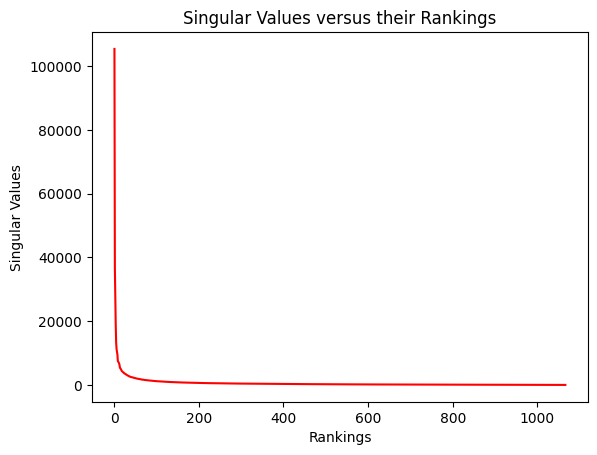

In [11]:
plt.plot(range(1, len(s) + 1), s, 'r-')
plt.xlabel("Rankings")
plt.ylabel("Singular Values")
plt.title("Singular Values versus their Rankings")
plt.savefig("Singular_values_vs_rankings.png")
plt.show()

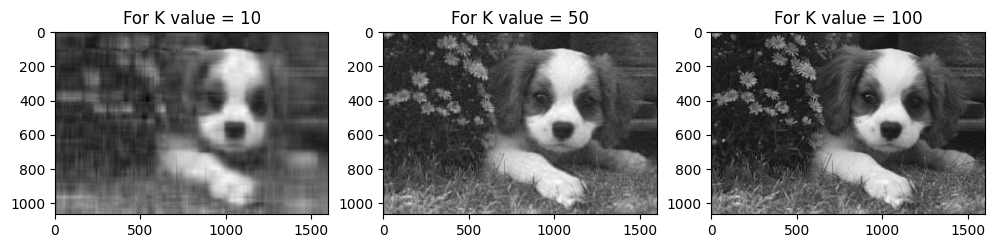

In [12]:
k_values = [10, 50, 100]

plt.figure(figsize=(12,6))

for i in range(len(k_values)):
    low_rank = U[:, :k_values[i]] @ np.diag(s[:k_values[i]]) @ V[:k_values[i], :]
    plt.subplot(2,3,i+1),
    plt.imshow(low_rank, cmap='gray'),
    plt.title(f"For K value = {k_values[i]}")
    plt.savefig("Reconstruction_with_k_values.png")